In [12]:
from sklearn.metrics import pairwise_distances
import matplotlib.pyplot as plt
from scipy.spatial import distance
import numpy as np
import pandas as pd
import pickle
import os

plt.rcParams['figure.dpi'] = 150

In [2]:
### STRUCTURE ###

In [3]:
# Get the proteins
fps_tRNAs = pickle.load(open("../processed/pocketvec_RUN/fps_rank.pkl", 'rb'))
proteins = sorted(set([i.split("_")[1] for i in fps_tRNAs]))

# Load structural comparisons
PATH_TO_RMSDs = "../processed/structural_comparisons"
RMSDs = {}
for c, protein1 in enumerate(proteins):
    for protein2 in proteins[c+1:]:
        df = pd.read_csv(os.path.join(PATH_TO_RMSDs, f"{protein1}_{protein2}_rmsd.csv"))
        filename1 = [i.replace(".pdb", "") for i in df['file_name_1']]
        filename2 = [i.replace(".pdb", "") for i in df['file_name_2']]
        rmsds = [float(i) for i in df['rmsd']]
        for fn1, fn2, rmsd in zip(filename1, filename2, rmsds):
            RMSDs[tuple([fn1, fn2])] = rmsd

# Calculate all RMSDs
h = [RMSDs[i] for i in sorted(RMSDs)]

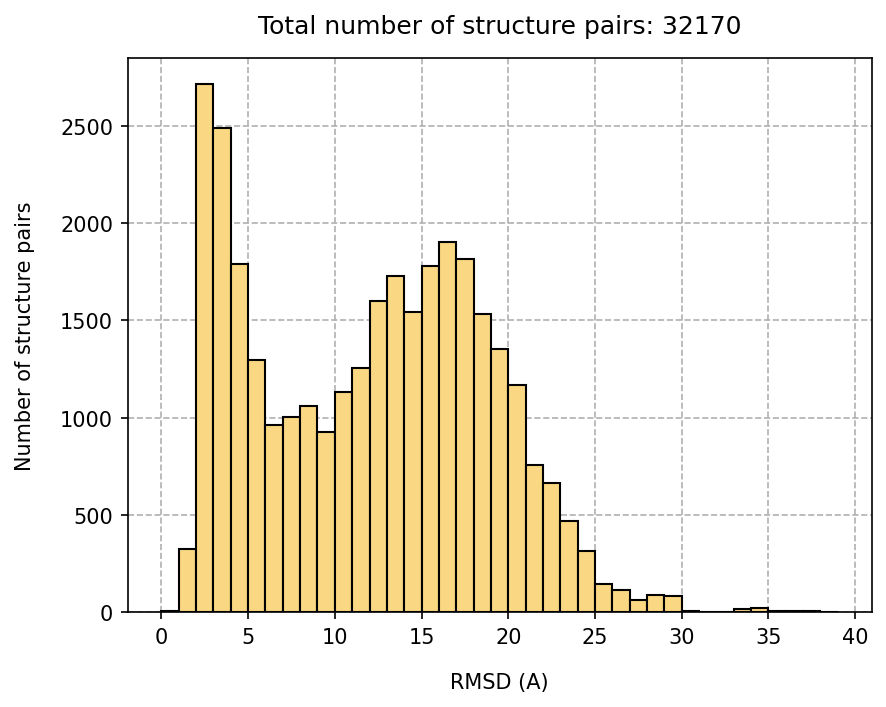

In [4]:
bins = [i for i in range(0, 40, 1)]

plt.hist(h, bins=bins, zorder=2, edgecolor='k', color='#FAD782')
title = f"Total number of structure pairs: {len(h)}"
plt.title(title, pad=12)
plt.ylabel("Number of structure pairs", labelpad=12)
plt.xlabel("RMSD (A)", labelpad=12)
plt.grid(linestyle='--', zorder=-2)
plt.show()

In [5]:
### SEQUENCE ###

In [6]:
# NW algorithm
PROP_NW = pd.read_csv("../processed/sequences/NW_SeqAlign/Prop_matrix.tsv", sep='\t', index_col=0)
PROP_NW.columns = PROP_NW.columns.str.replace('(tRNA)', '')
PROP_NW.index = PROP_NW.index.str.replace('(tRNA)', '')
PROP_NW.columns = PROP_NW.columns.str.strip()
PROP_NW.index = PROP_NW.index.str.strip()
PROP_NW = PROP_NW.stack().to_dict()

SEQ_ID_NW = pd.read_csv("../processed/sequences/NW_SeqAlign/SeqId_matrix.tsv", sep='\t', index_col=0)
SEQ_ID_NW.columns = SEQ_ID_NW.columns.str.replace('(tRNA)', '')
SEQ_ID_NW.index = SEQ_ID_NW.index.str.replace('(tRNA)', '')
SEQ_ID_NW.columns = SEQ_ID_NW.columns.str.strip()
SEQ_ID_NW.index = SEQ_ID_NW.index.str.strip()
SEQ_ID_NW = SEQ_ID_NW.stack().to_dict()

# CLUSTAL OMEGA
with open('../processed/sequences/MSA_ClustalOmega/clustalo-I20250414-162824-0073-80384311-p1m.pim') as f:
    lines = f.readlines()
lines = [i for i in lines if i.startswith('#') == False and len(i.strip()) > 0]
clustal_omega = {}
for i, line in enumerate(lines):
    parts = line.split()
    uniprot_1 = parts[1].split('|')[0]
    seq_identities = list(map(float, parts[2:]))
    for j, identity in enumerate(seq_identities):
        uniprot_2 = lines[j].split()[1].split('|')[0]
        clustal_omega[(uniprot_1, uniprot_2)] = identity

h1 = [SEQ_ID_NW[i] for i in sorted(SEQ_ID_NW) if i[0] in proteins and i[1] in proteins]
h2 = [clustal_omega[i] for i in sorted(clustal_omega) if i[0] in proteins and i[1] in proteins]


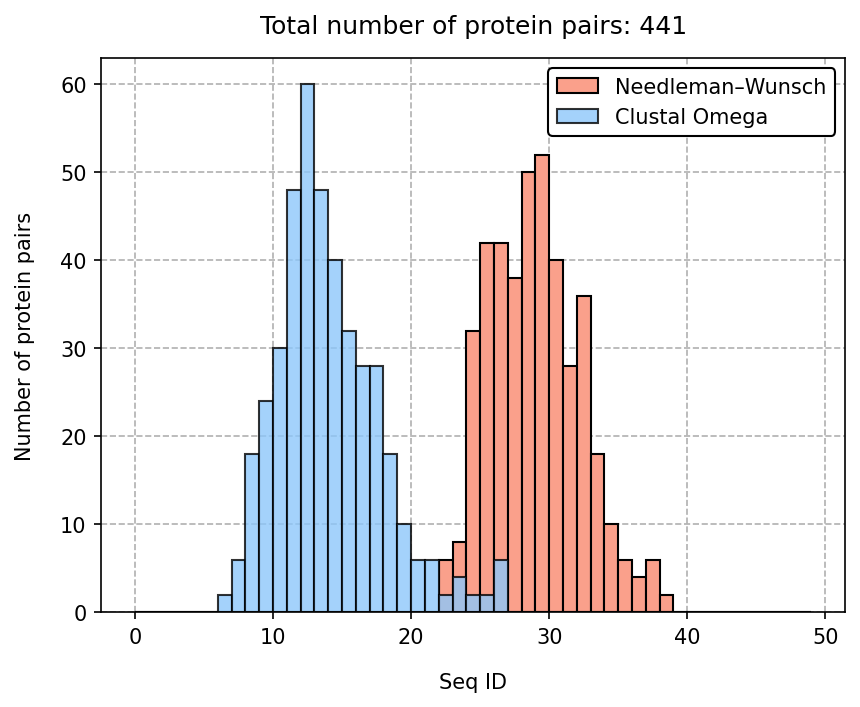

In [7]:
bins = [i for i in range(0, 50, 1)]

plt.hist(h1, bins=bins, zorder=2, edgecolor='k', color='#FAA08B', label='Needleman–Wunsch')
plt.hist(h2, bins=bins, zorder=2, edgecolor='k', color='#8DC7FA', label='Clustal Omega', alpha=0.8)


title = f"Total number of protein pairs: {len(h1)}"
plt.title(title, pad=12)
plt.ylabel("Number of protein pairs", labelpad=12)
plt.xlabel("Seq ID", labelpad=12)
plt.grid(linestyle='--', zorder=-2)
plt.legend(framealpha=1, edgecolor='k')
plt.show()

In [8]:
### POCKETVEC ###

In [23]:
# Get PocketVec descriptors
fps_tRNAs = pickle.load(open("../processed/pocketvec_RUN/fps_rank.pkl", 'rb'))
proteins = sorted(set([i.split("_")[1] for i in fps_tRNAs]))

# X = np.array([fps_tRNAs[i] for i in sorted(fps_tRNAs)])
# X = pairwise_distances(X, metric='cosine')

# upper_indices = np.triu_indices(X.shape[0], k=1)
# X = X[upper_indices]

# For each protein, get list of pockets
protein_to_pockets = {}
for p in sorted(set(proteins)):
    protein_to_pockets[p] = [i for i in fps_tRNAs if i.split("_")[1] == p]

X = []

for c, protein1 in enumerate(proteins):
    for protein2 in proteins[c+1:]:

        # Get the list of pockets for each protein
        pockets1 = protein_to_pockets[protein1]
        pockets2 = protein_to_pockets[protein2]

        for pocket1 in pockets1:
            for pocket2 in pockets2:
                # Get the PocketVec descriptors
                X.append(distance.cosine(fps_tRNAs[pocket1], fps_tRNAs[pocket2]))

In [26]:
len(X)

35573

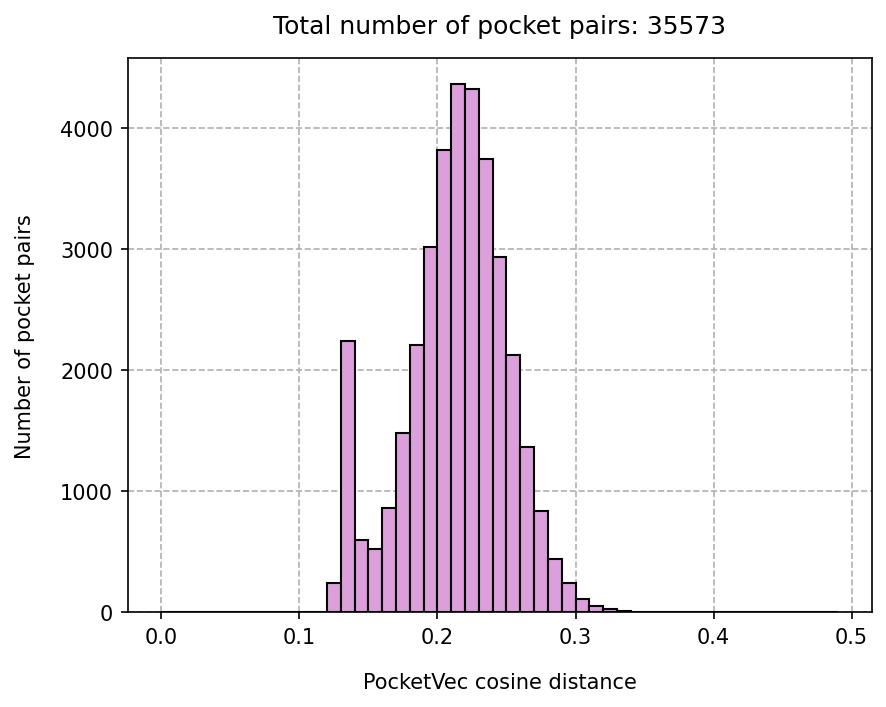

In [27]:
bins = [i for i in np.arange(0, 0.5, 0.01)]

plt.hist(X, bins=bins, zorder=2, edgecolor='k', color='#DC9FDC')
title = f"Total number of pocket pairs: {len(X)}"
plt.title(title, pad=12)
plt.ylabel("Number of pocket pairs", labelpad=12)
plt.xlabel("PocketVec cosine distance", labelpad=12)
plt.grid(linestyle='--', zorder=-2)
plt.show()

In [86]:
### P2RANK SCORES ###

In [99]:
# Load P2Rank scores
p2rank = pd.read_csv("../processed/pocket_detection_data.csv")
pocket_to_p2rank_score = {i.replace(".pdb", "") + "_pocket_" + str(j): k for i,j,k in zip(p2rank['File name'], p2rank['Pocket number'], p2rank['Pocket score'])}
scores = [pocket_to_p2rank_score[i] for i in pocket_to_p2rank_score]

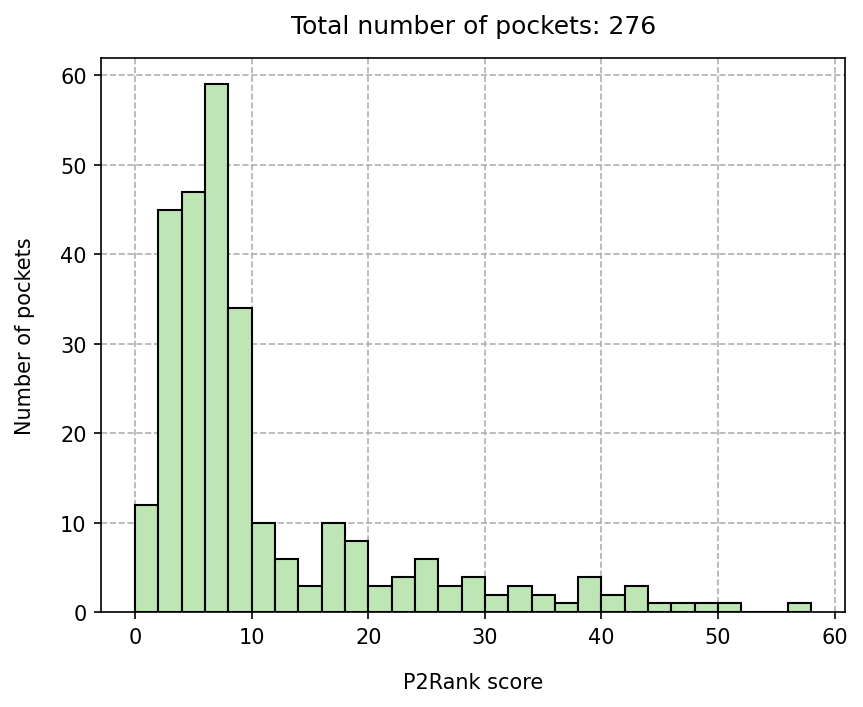

In [102]:
bins = [i for i in range(0, 60, 2)]

plt.hist(scores, bins=bins, zorder=2, edgecolor='k', color='#BEE6B4')
title = f"Total number of pockets: {len(scores)}"
plt.title(title, pad=12)
plt.ylabel("Number of pockets", labelpad=12)
plt.xlabel("P2Rank score", labelpad=12)
plt.grid(linestyle='--', zorder=-2)
plt.show()